In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
import warnings
warnings.filterwarnings('ignore')

In [112]:
data = pd.read_csv('insurance.csv')

In [113]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [114]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [115]:
data.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [116]:
data.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [117]:
data.isnull().sum()
#isnull() function is used to check for missing values in the dataset. 
#The sum() function is then applied to count the number of missing values in each column.
#This helps to identify if there are any null or missing values that need to be handled before further analysis.

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [148]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

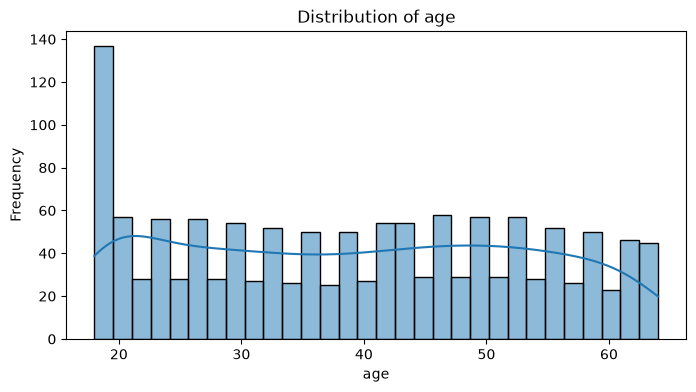

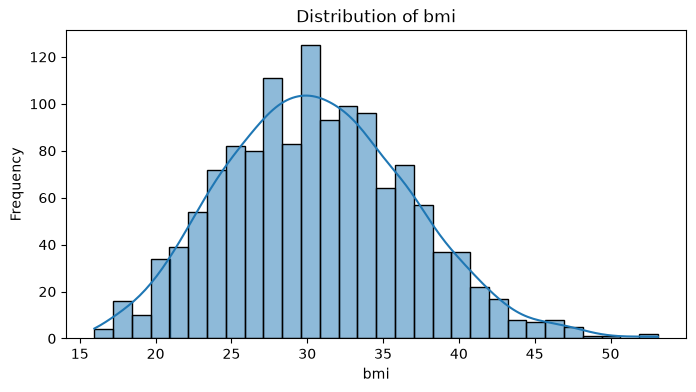

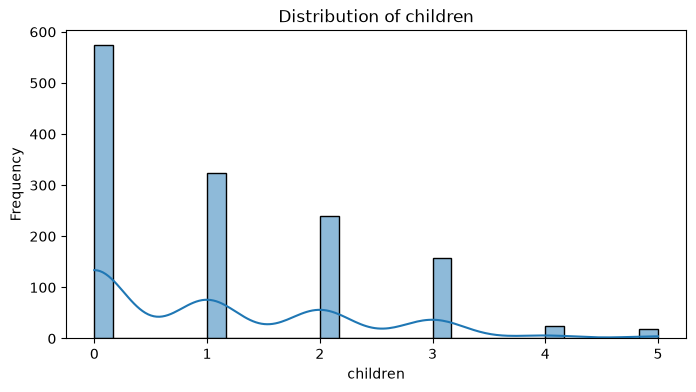

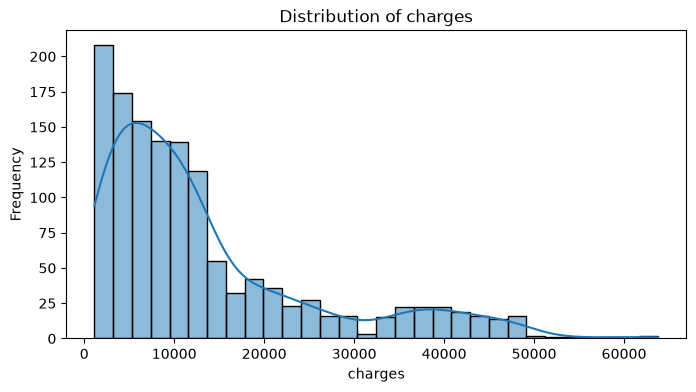

In [149]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(8, 4)) #double the size of the plot
    sns.histplot(data[col], kde=True, bins=30) #create a histogram with a kernel density estimate
    plt.title(f'Distribution of {col}') #set the title of the plot
    plt.xlabel(col) #set the x-axis label
    plt.ylabel('Frequency') #set the y-axis label
    plt.show() #display the plot


EDA


<Axes: xlabel='sex', ylabel='count'>

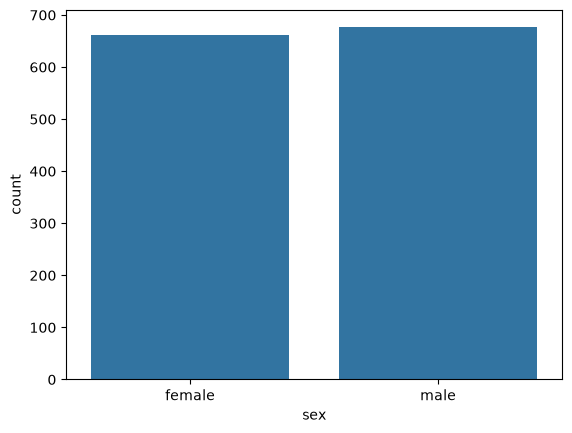

In [150]:
sns.countplot(x='sex', data=data)

<Axes: xlabel='smoker', ylabel='count'>

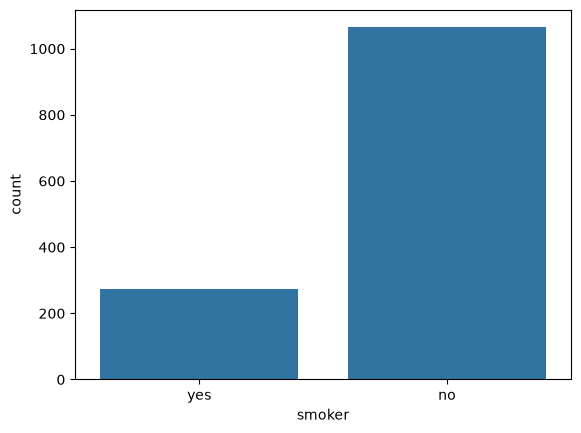

In [151]:
sns.countplot(x='smoker', data=data)

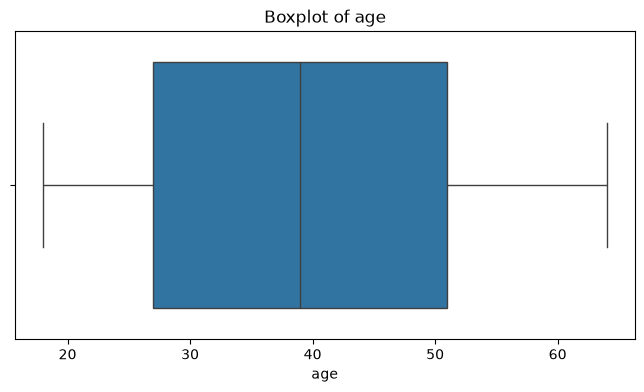

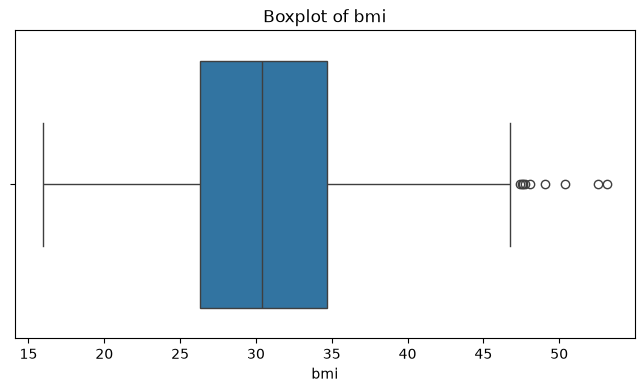

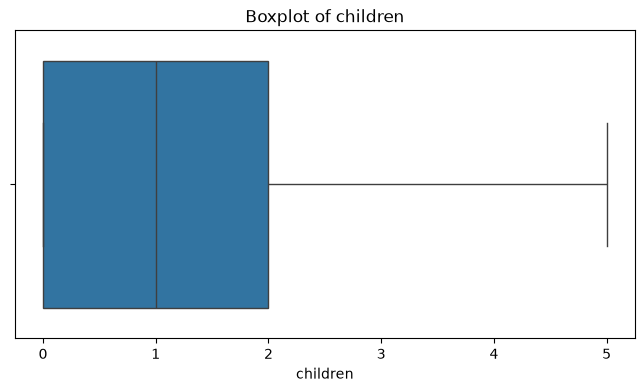

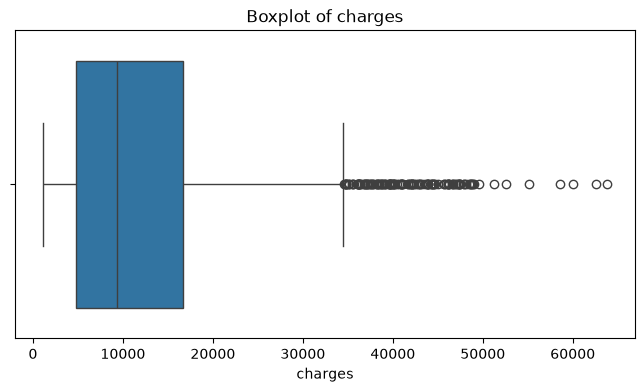

In [152]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

<Axes: >

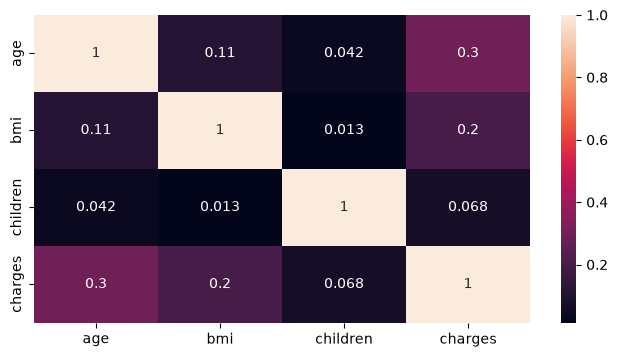

In [153]:
plt.figure(figsize=(8, 4))
sns.heatmap(data.corr(numeric_only=True), annot=True)

DATA CLEANING AND PROCESSING


In [154]:
data_cleaned = data.copy()

In [155]:
data_cleaned.drop_duplicates(inplace=True)
#inplace=True modifies the original DataFrame without creating a new one. 
# This is useful for saving memory and avoiding unnecessary copies of the data.

In [156]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [157]:
data_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [158]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [159]:
data_cleaned['sex'] = data_cleaned['sex'].map({'male': 0, 'female': 1})

In [160]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'yes': 1, 'no': 0})
data_cleaned.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region          str
charges     float64
dtype: object

In [161]:
data_cleaned = pd.get_dummies(data_cleaned, columns=['region'], drop_first=True)

In [162]:
data_cleaned.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [163]:
data_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [164]:
data_cleaned = data_cleaned.fillna(0).astype(int)
data_cleaned.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


FEATURE ENGINEERING AND EXTRACTION 

<Axes: xlabel='bmi', ylabel='Count'>

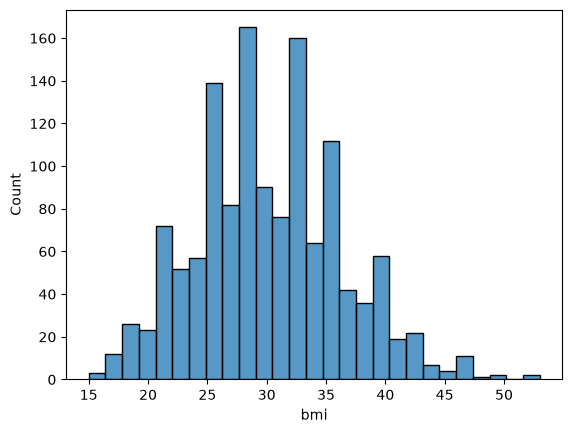

In [165]:
sns.histplot(data_cleaned['bmi'])

In [178]:
# 1. Reload original dataset to get unscaled BMI values
from sklearn.preprocessing import MinMaxScaler


data_cleaned = pd.read_csv('insurance.csv')

# 2. Bin original BMI into categories
data_cleaned['bmi_cat'] = pd.cut(
    data_cleaned['bmi'], 
    bins=[0, 18.5, 24.9, 29.9, np.inf], 
    labels=['Underweight', 'Normal weight', 'Overweight', 'Obesity'],
    right=False
)

# 3. One-hot encode BMI categories into 0/1 integers
bmi_dummies = pd.get_dummies(data_cleaned['bmi_cat'], prefix='bmi', dtype=int)

# 4. Join encoded columns back and drop temporary columns
data_cleaned = pd.concat([data_cleaned, bmi_dummies], axis=1).drop(columns=['bmi_cat', 'bmi'])

# 5. Apply MinMaxScaler AFTER binning on continuous numerical features
cols = ['age', 'children']  # Apply scaler to continuous numeric features only
scaler = MinMaxScaler()
data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])

In [179]:
data_cleaned.head()

,age,sex,children,smoker,region,charges,bmi_Underweight,bmi_Normal weight,bmi_Overweight,bmi_Obesity
0,0.021739,female,0.0,yes,southwest,16884.92400,0,0,1,0
1,0.000000,male,0.2,no,southeast,1725.55230,0,0,0,1
2,0.217391,male,0.6,no,southeast,4449.46200,0,0,0,1
3,0.326087,male,0.0,no,northwest,21984.47061,0,1,0,0
4,0.304348,male,0.0,no,northwest,3866.85520,0,0,1,0


KeyError: "None of [Index(['bmi'], dtype='str')] are in the [columns]"

In [182]:
# Option A: Convert boolean columns automatically
bool_cols = data_cleaned.select_dtypes(include=['bool']).columns
data_cleaned[bool_cols] = data_cleaned[bool_cols].astype(int)

data_cleaned.head()

,age,sex,children,smoker,region,charges,bmi_Underweight,bmi_Normal weight,bmi_Overweight,bmi_Obesity
0,0.021739,female,0.0,yes,southwest,16884.92400,0,0,1,0
1,0.000000,male,0.2,no,southeast,1725.55230,0,0,0,1
2,0.217391,male,0.6,no,southeast,4449.46200,0,0,0,1
3,0.326087,male,0.0,no,northwest,21984.47061,0,1,0,0
4,0.304348,male,0.0,no,northwest,3866.85520,0,0,1,0


In [183]:
data_cleaned.columns

Index(['age', 'sex', 'children', 'smoker', 'region', 'charges',
       'bmi_Underweight', 'bmi_Normal weight', 'bmi_Overweight',
       'bmi_Obesity'],
      dtype='str')

In [ ]:
#now we have to bring age and bmi into the same scale. We can use MinMaxScaler to scale the values between 0 and 1.

In [184]:
from sklearn.preprocessing import MinMaxScaler

In [185]:
cols = ['age','children']
scaler = MinMaxScaler()
data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])

In [186]:
data_cleaned.head()

,age,sex,children,smoker,region,charges,bmi_Underweight,bmi_Normal weight,bmi_Overweight,bmi_Obesity
0,0.021739,female,0.0,yes,southwest,16884.92400,0,0,1,0
1,0.000000,male,0.2,no,southeast,1725.55230,0,0,0,1
2,0.217391,male,0.6,no,southeast,4449.46200,0,0,0,1
3,0.326087,male,0.0,no,northwest,21984.47061,0,1,0,0
4,0.304348,male,0.0,no,northwest,3866.85520,0,0,1,0


In [187]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'no': 0, 'yes': 1}).astype(int)

data_cleaned['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [188]:
data_cleaned.head()

,age,sex,children,smoker,region,charges,bmi_Underweight,bmi_Normal weight,bmi_Overweight,bmi_Obesity
0,0.021739,female,0.0,1,southwest,16884.92400,0,0,1,0
1,0.000000,male,0.2,0,southeast,1725.55230,0,0,0,1
2,0.217391,male,0.6,0,southeast,4449.46200,0,0,0,1
3,0.326087,male,0.0,0,northwest,21984.47061,0,1,0,0
4,0.304348,male,0.0,0,northwest,3866.85520,0,0,1,0


In [ ]:
data_cleaned = pd.get_dummies(
    data_cleaned,
    columns=['region'],
    dtype=int
)

data_cleaned.head()